In [51]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import os
import geopandas as gpd


In [76]:
# Load data
climate_adm2 = pd.read_csv("../../data/raw/features/climate_features_lka_19.csv")
ml_targets = pd.read_csv("../../data/processed/sl_ml_targets_2025-11-13.csv")
hh_info = pd.read_csv("../../data/processed/hh_info.csv")
adm2_average = pd.read_csv("../../data/processed/adm2_average.csv")


# read in raw climate features
path_to_directory = 'C:/Users/gabriel.battcock/OneDrive - World Food Programme/General - MIMI Project/data_science/country_analysis/lka/'
climate_monthly = pd.read_csv(path_to_directory + 'raw_climate_feature_SL.csv')

#


In [78]:

adm2_average

,adm2,energy_kcal_q50,energy_kcal_q50_se,ca_mg_q50,ca_mg_q50_se,mg_mg_q50,mg_mg_q50_se,fe_mg_q50,fe_mg_q50_se,zn_mg_q50,zn_mg_q50_se,thia_mg_q50,thia_mg_q50_se,ribo_mg_q50,ribo_mg_q50_se,niac_mg_q50,niac_mg_q50_se,vitb6_mg_q50,vitb6_mg_q50_se,vitc_mg_q50,vitc_mg_q50_se,protein_g_q50,protein_g_q50_se,fat_g_q50,fat_g_q50_se,carbohydrate_g_q50,carbohydrate_g_q50_se,fibre_g_q50,fibre_g_q50_se,starch_g_q50,starch_g_q50_se,cholesterol_g_q50,cholesterol_g_q50_se,vitb12_mcg_q50,vitb12_mcg_q50_se,folate_mcg_q50,folate_mcg_q50_se,vita_rae_mcg_q50,vita_rae_mcg_q50_se,vite_mcg_q50,vite_mcg_q50_se,vita_inad,vita_inad_se,zn_inad,zn_inad_se,folate_inad,folate_inad_se,thia_inad,thia_inad_se,vitb12_inad,vitb12_inad_se,fe_inad
0,11,1872.295308,16.663122,455.731880,5.361542,154.431177,1.921288,9.896127,0.098297,7.568138,0.089987,0.839178,0.008099,0.698174,0.009018,8.593633,0.077278,0.922176,0.010504,30.568625,0.590619,57.226472,0.572817,54.451936,0.577463,283.605398,2.969200,22.566615,0.256190,33.403371,0.925754,53.704273,0.817782,1.164260,0.025778,187.127905,2.101151,193.781450,3.002329,0,0,97.320387,4.146648e-01,87.183507,0.860197,81.844796,1.073947,59.743869,1.385496,82.238117,1.045527,78.957650
1,12,1922.323669,20.501485,428.136241,7.211011,159.544137,1.875397,9.980315,0.123978,7.595581,0.085291,0.830605,0.008831,0.678448,0.010631,8.579428,0.115876,0.928178,0.012507,28.096760,0.552301,57.193420,0.751221,57.513990,0.886260,292.665477,3.574873,23.459890,0.385958,33.739402,1.239502,53.211816,1.054739,1.146311,0.026251,192.662570,2.566671,167.079039,3.486096,0,0,97.819662,4.377599e-01,83.642204,1.129257,76.056013,1.325401,60.666974,1.516520,83.836805,1.092432,77.445997
2,13,2018.012131,25.072159,391.913361,6.620504,166.280214,2.012130,9.759941,0.122473,8.128786,0.084404,0.880784,0.011179,0.633975,0.008265,8.757214,0.110400,0.905884,0.015334,26.339418,0.694576,59.554939,0.697222,52.173867,0.966256,323.975313,3.702305,23.750113,0.275743,27.060978,1.218638,52.055012,1.200573,1.151607,0.027784,189.665231,3.061989,157.505846,4.857071,0,0,97.949489,4.185460e-01,80.529370,1.404218,81.121433,1.428539,53.115583,1.761463,84.157322,1.215177,79.818891
3,21,1916.842844,30.831254,363.561476,8.933607,134.063044,2.483684,8.812968,0.134932,7.307671,0.110290,0.814289,0.011775,0.585011,0.010866,7.596644,0.108397,0.866459,0.014561,28.659533,0.884897,51.656248,0.676101,52.974234,0.896040,299.257292,3.682766,22.117777,0.288167,20.383647,0.900236,49.303612,1.356933,0.865130,0.030076,164.180752,3.417583,153.483332,3.811203,0,0,98.173099,3.631053e-01,88.947145,0.890745,85.651582,1.175243,63.710986,1.779443,91.988356,0.873882,84.891473
4,22,1947.599994,52.394253,334.792754,9.409328,138.928448,3.897140,8.871641,0.178795,7.463490,0.179548,0.817896,0.017990,0.563490,0.018488,7.590853,0.191473,0.892218,0.024907,27.112383,0.856691,51.656840,1.106016,57.416403,1.282071,306.093231,7.580420,23.140606,0.530619,17.736180,1.335717,46.526549,1.716528,0.847131,0.035430,165.026210,4.608217,124.301714,3.674439,0,0,98.359475,5.416011e-01,81.612731,1.816827,84.983630,1.560577,61.645237,2.354747,88.854730,1.332794,82.389351
5,23,2008.120260,40.317898,307.949590,11.281918,124.182982,3.765478,9.354087,0.260359,7.396211,0.139329,0.864749,0.016401,0.558956,0.013074,7.687323,0.173554,0.843057,0.017460,23.092957,1.014487,53.368189,1.218249,47.634643,1.666735,330.993262,6.476984,22.789088,0.517160,15.207164,1.332809,70.715572,3.346230,0.758911,0.038545,159.778872,3.697482,122.223561,5.085085,0,0,98.541107,4.265682e-01,81.739948,1.722187,86.898868,1.451075,54.184541,2.363716,94.026034,0.973012,81.146245
6,31,1929.539386,27.153221,399.107524,9.766792,167.690351,3.428110,9.696052,0.176992,8.007232,0.135969,0.834064,0.010688,0.645740,0.012302,8.494925,0.136802,0.877791,0.017018,25.440797,0.655877,58.678339,0.786414,52.893303,0.971895,300.698488,4.307745,24.107135,0.445038,24.606765,1.349150,51.966682,1.523523,1.305644,0.041280,184.214123,4.369066,154.079051,4.021990,0,0,97.312984,4.517862e-01,75.524

## Year long average climate features

In [70]:

# Merge and summarize climate data
climate_adm2 = (
    climate_adm2
    .merge(ml_targets[['hhid', 'overall_mar']], left_on='household_id', right_on='hhid', how='left')
    .merge(hh_info[['hhid', 'adm2']].assign(hhid=lambda df: pd.to_numeric(df['hhid'], errors='coerce')),
           left_on='household_id', right_on='hhid', how='left')
    .groupby('adm2', as_index=False)
    .agg({
        'r3q': 'mean',
        'rfh_avg': 'mean',
        'vim_avg': 'mean',
        'overall_mar': 'mean'
    })
    .rename(columns={'overall_mar': 'mar'})
)

,adm2,r3q,rfh_avg,vim_avg,mar
0,11,105.49575,80.47100,0.69605,0.651882
1,12,108.25955,62.87160,0.74320,0.641391
2,13,107.90530,88.35610,0.79245,0.647957
3,21,108.28605,58.97725,0.78345,0.577657
4,22,104.50970,48.32415,0.76940,0.578159
5,23,103.89535,72.19365,0.77405,0.558633
6,31,104.88385,78.63580,0.79895,0.649656
7,32,103.74020,66.17730,0.80245,0.648014
8,33,102.58805,34.44690,0.70350,0.633563
9,41,89.11320,12.93815,0.50065,0.600254


In [71]:

# Merge with nutrition indicators
adm2_inad = (
    adm2_average[['adm2', 'energy_kcal_q50'] + [col for col in adm2_average.columns if col.endswith('_inad')]]
    .merge(climate_adm2, on='adm2', how='left')
)

# Add province names
province_map = {
    1: "Western", 2: "Central", 3: "Southern", 4: "Northern", 5: "Eastern",
    6: "North Western", 7: "North Central", 8: "Uva", 9: "Sabaragamuwa"
}
adm2_inad['province'] = (adm2_inad['adm2'] // 10).round().map(province_map)

In [72]:

# Define variable groups
mn_col_names = list(adm2_inad.columns[2:8]) + [adm2_inad.columns[11]]
clim_col_names = list(adm2_inad.columns[8:11])

# Create output directory
os.makedirs("../../outputs/plots/climate", exist_ok=True)


# sns.pairplot(adm2_inad, vars=mn_col_names + clim_col_names, hue="province")
# # Generate plots
# for i in mn_col_names:
#     for j in clim_col_names:
#         print(f"Plotting {i} vs {j}")
#         plt.figure(figsize=(8, 6))
#         sns.scatterplot(data=adm2_inad, x=j, y=i, hue='province', s=50)
#         sns.regplot(data=adm2_inad, x=j, y=i, scatter=False, color='black')

        
#         X = sm.add_constant(adm2_inad[j])
#         y = adm2_inad[i]

#         # Combine X and y into a single DataFrame for cleaning
#         data = pd.concat([X, y], axis=1)

#         # Remove rows with NaN or inf values
#         data_clean = data.replace([np.inf, -np.inf], np.nan).dropna()

#         # Separate cleaned X and y
#         X_clean = data_clean.iloc[:, :-1]
#         y_clean = data_clean.iloc[:, -1]

#         # Fit the model
#         model = sm.OLS(y_clean, X_clean).fit()

#         r_squared = model.rsquared
#         intercept, slope = model.params

#         pearson_r = model.params[1] / abs(model.params[1]) * r_squared**0.5

#         # Annotate with R² and equation
#         eq_label = f"$y = {intercept:.2f} + {slope:.2f}x$\n$R^2 = {r_squared:.2f}$\n$Pearson = {pearson_r:.2f}$"
#         plt.text(0.05, 0.95, eq_label, transform=plt.gca().transAxes,
#                  verticalalignment='top', horizontalalignment='left', fontsize=10)

#         plt.title(f"Scatterplot of {i} vs {j}")
#         plt.tight_layout()
#         plt.savefig(f"outputs/plots/climate/{i}_{j}.png")
#         plt.close()




## Monthly changes


In [73]:
climate_monthly['month'] = pd.to_datetime(climate_monthly['dates'], format="%Y-%m-%d").dt.strftime("%B")
climate_monthly['year'] = pd.to_datetime(climate_monthly['dates'], format="%Y-%m-%d").dt.strftime("%Y")

climate_monthly


,Unnamed: 0,rfh,rfh_avg,r1h,r1h_avg,r3h,r3h_avg,rfq,r1q,r3q,vim,vim_avg,viq,dates,adm2Code,adm1Geometry,adm1Code,adm1Name,adm2Name,adm2Geometry,adm2Name_y,month,year
0,0,7.1167,65.4006,60.7000,242.5900,487.5833,913.6005,17.2110,26.5358,53.6232,0.8020,0.8029,99.8921,2017-01-01,41748,"POLYGON ((80.9883 7.7204, 80.9851 7.7197, 80.9...",2736,Central,Kandy,"POLYGON ((80.974 7.4887, 80.9618 7.4887, 80.95...",Kandy,January,2017
1,1,6.4167,59.6306,49.3500,208.9189,468.7500,860.7461,17.6645,25.4068,54.7216,0.7999,0.7988,100.1393,2017-01-11,41748,"POLYGON ((80.9883 7.7204, 80.9851 7.7197, 80.9...",2736,Central,Kandy,"POLYGON ((80.974 7.4887, 80.9618 7.4887, 80.95...",Kandy,January,2017
2,2,186.6500,55.0483,200.1833,180.0794,608.0000,787.8400,319.1595,110.8623,77.3170,0.7977,0.7938,100.4704,2017-01-21,41748,"POLYGON ((80.9883 7.7204, 80.9851 7.7197, 80.9...",2736,Central,Kandy,"POLYGON ((80.974 7.4887, 80.9618 7.4887, 80.95...",Kandy,January,2017
3,3,2.4333,45.1017,195.5000,159.7805,470.8000,717.3878,14.8365,121.6770,65.8649,0.7951,0.7882,100.8257,2017-02-01,41748,"POLYGON ((80.9883 7.7204, 80.9851 7.7197, 80.9...",2736,Central,Kandy,"POLYGON ((80.974 7.4887, 80.9618 7.4887, 80.95...",Kandy,February,2017
4,4,29.6167,33.3478,218.7000,133.4978,373.0500,642.5850,90.2703,161.5188,58.3784,0.7922,0.7827,101.1447,2017-02-11,41748,"POLYGON ((80.9883 7.7204, 80.9851 7.7197, 80.9...",2736,Central,Kandy,"POLYGON ((80.974 7.4887, 80.9618 7.4887, 80.95...",Kandy,February,2017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2695,2695,149.2500,130.8282,460.2308,424.5731,2278.7308,1146.0570,113.5626,108.3007,198.4029,0.8092,0.7984,101.2790,2019-11-11,25853,"POLYGON ((80.1789 6.8028, 80.1768 6.8121, 80.1...",2744,Western,Kalutara,"POLYGON ((80.1494 6.8241, 80.1484 6.8239, 80.1...",Kalutara,November,2019
2696,2696,155.0962,139.0070,402.7885,405.2455,2127.3460,1209.5430,111.1724,99.4011,175.5678,0.8094,0.7985,101.2740,2019-11-21,25853,"POLYGON ((80.1789 6.8028, 80.1768 6.8121, 80.1...",2744,Western,Kalutara,"POLYGON ((80.1494 6.8241, 80.1484 6.8239, 80.1...",Kalutara,November,2019
2697,2697,81.4615,85.1885,385.8077,355.0237,2083.5768,1185.0295,95.8676,108.5506,175.5063,0.8092,0.7982,101.2962,2019-12-01,25853,"POLYGON ((80.1789 6.8028, 80.1768 6.8121, 80.1...",2744,Western,Kalutara,"POLYGON ((80.1494 6.8241, 80.1484 6.8239, 80.1...",Kalutara,December,2019
2698,2698,62.1923,75.8167,298.7500,300.0122,1682.2884,1144.7224,83.1416,99.5862,146.7562,0.8083,0.7969,101.3466,2019-12-11,25853,"POLYGON ((80.1789 6.8028, 80.1768 6.8121, 80.1...",2744,Western,Kalutara,"POLYGON ((80.1494 6.8241, 80.1484 6.8239, 80.1...",Kalutara,December,2019


Just same month of survey (filter 2019)

In [74]:
def filter_year(year: str):
# Filter for 2019 and aggregate monthly averages
    agg_df = (
        climate_monthly[climate_monthly['year'] == year]
        .groupby(['month', 'year', 'adm2Code'])
        .agg({
            'r3q': 'mean',
            'rfh_avg': 'mean',
            'vim_avg': 'mean'
        })
        .reset_index()
    )


    # Convert month names to numbers
    agg_df['month_num'] = pd.to_datetime(agg_df['month'], format='%B').dt.month

    # Sort by adm2Code and numeric month
    agg_df = agg_df.sort_values(['adm2Code', 'month_num'])

    return agg_df


    # # Compute rolling 3-month average per adm2Code
    # rolling_df = (
    #     agg_df.groupby('adm2Code')[['r3q', 'rfh_avg', 'vim_avg']]
    #     .rolling(window=3, min_periods=1)
    #     .mean()
    #     .reset_index()
    # )

    # # Add month/year back correctly
    # rolling_df['month'] = agg_df['month'].values
    # rolling_df['year'] = agg_df['year'].values

    # rolling_df
    


In [75]:
ml_targets

,iso3,survey,hhid,month,vita_rae_mcg,folate_mcg,vitb12_mcg,fe_mg,zn_mg,overall_mar
0,LKA,lka_hies19,11100111,1,141.771251,203.900155,0.664669,10.511153,7.443397,0.594869
1,LKA,lka_hies19,11100121,1,156.913148,294.643247,2.095717,16.224352,12.205733,0.864046
2,LKA,lka_hies19,11100131,1,129.682588,157.911251,0.570306,15.480013,9.110019,0.636291
3,LKA,lka_hies19,11100141,1,68.646014,155.070328,1.249101,7.259847,4.729379,0.480061
4,LKA,lka_hies19,11100151,1,199.522686,204.118187,1.003891,10.476471,8.111925,0.667098
...,...,...,...,...,...,...,...,...,...,...
19906,LKA,lka_hies19,19208551,12,66.503481,169.805471,0.792777,9.284953,9.448862,0.566066
19907,LKA,lka_hies19,19208561,12,126.022109,202.143046,0.979918,12.717502,11.817528,0.680711
19908,LKA,lka_hies19,19208571,12,107.433567,108.421219,0.560491,8.051044,7.167088,0.455042
19909,LKA,lka_hies19,19208581,12,81.682584,150.781143,1.035865,9.860609,10.237976,0.589026


In [66]:
ml_targets['vita_inad'] = np.where(ml_targets['vita_rae_mcg'] < 490, 1, 0)
ml_targets['folate_inad'] = np.where(ml_targets['folate_mcg'] < 250, 1, 0)
ml_targets['vitb12_inad'] = np.where(ml_targets['vitb12_mcg'] < 2, 1, 0)
ml_targets['fe_inad'] = np.where(ml_targets['fe_mg'] < 15, 1, 0)
ml_targets['zn_inad'] = np.where(ml_targets['zn_mg'] < 8.9, 1, 0)
ml_targets

,iso3,survey,hhid,month,vita_rae_mcg,folate_mcg,vitb12_mcg,fe_mg,zn_mg,overall_mar,vita_inad,folate_inad,vitb12_inad,fe_inad,zn_inad,zone,adm1,adm2,ea,res,sep_quintile,res_quintile,year,survey_wgt,pc_expenditure,afe
0,LKA,lka_hies19,11100111,January,141.771251,203.900155,0.664669,10.511153,7.443397,0.594869,1,1,1,1,1,NaN,1,11,111001,Urban,4,Urban 3,2019,298.042313,21900.952000,5.898618
1,LKA,lka_hies19,11100121,January,156.913148,294.643247,2.095717,16.224352,12.205733,0.864046,1,0,0,0,0,NaN,1,11,111001,Urban,5,Urban 4,2019,298.042313,24959.200000,4.589862
2,LKA,lka_hies19,11100131,January,129.682588,157.911251,0.570306,15.480013,9.110019,0.636291,1,1,1,0,0,NaN,1,11,111001,Urban,5,Urban 4,2019,298.042313,30240.623000,0.953917
3,LKA,lka_hies19,11100141,January,68.646014,155.070328,1.249101,7.259847,4.729379,0.480061,1,1,1,1,1,NaN,1,11,111001,Urban,2,Urban 1,2019,298.042313,10327.734429,7.377880
4,LKA,lka_hies19,11100151,January,199.522686,204.118187,1.003891,10.476471,8.111925,0.667098,1,1,1,1,1,NaN,1,11,111001,Urban,4,Urban 3,2019,298.042313,18640.097750,4.493088
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19906,LKA,lka_hies19,19208551,December,66.503481,169.805471,0.792777,9.284953,9.448862,0.566066,1,1,1,1,0,NaN,9,92,192085,Estate,2,Estate 3,2019,259.314922,8414.206333,3.442396
19907,LKA,lka_hies19,19208561,December,126.022109,202.143046,0.979918,12.717502,11.817528,0.680711,1,1,1,1,0,NaN,9,92,192085,Estate,3,Estate 5,2019,259.314922,14566.237600,6.926267
19908,LKA,lka_hies19,19208571,December,107.433567,108.421219,0.560491,8.051044,7.167088,0.455042,1,1,1,1,1,NaN,9,92,192085,Estate,1,Estate 2,2019,259.314922,7628.548000,2.064516
19909,LKA,lka_hies19,19208581,December,81.682584,150.781143,1.035865,9.860609,10.237976,0.589026,1,1,1,1,0,NaN,9,92,192085,Estate,1,Estate 2,2019,259.314922,6568.597000,6.018433


In [68]:
ml_targets = ml_targets.merge(hh_info)
ml_targets['adm2'] = ml_targets['adm2'].astype(int)
    # Ensure ml_targets key column is also int
ml_targets = ml_targets.merge(hh_info)
ml_targets['adm2'] = ml_targets['adm2'].astype(int)

ml_targets['month'] = pd.to_datetime(ml_targets['month'], format="%m").dt.strftime("%B")
ml_targets['year'] = pd.to_datetime(ml_targets['year'], format="%Y").dt.strftime("%Y")

ml_aggregate = ml_targets.groupby(['month', 'year', 'adm2']).agg({
        'vita_rae_mcg':'median',
         'folate_mcg':'median',
         	'vitb12_mcg':'median',	'fe_mg':'median',	'zn_mg':'median',
            'overall_mar':'mean',
        'vita_inad': 'mean',
        'folate_inad': 'mean',
        'vitb12_inad': 'mean',
        'fe_inad': 'mean',
        'zn_inad': 'mean'
    }) .reset_index()

# ml_aggregate

# ml_targets
# .groupby(['adm2']).agg({
#         'vita_rae_mcg':'median',
#          'folate_mcg':'median',
#          	'vitb12_mcg':'median',	'fe_mg':'median',	'zn_mg':'median',
#             'overall_mar':'mean',
#         'vita_inad': 'mean',
#         'folate_inad': 'mean',
#         'vitb12_inad': 'mean',
#         'fe_inad': 'mean',
#         'zn_inad': 'mean'
#     }).reset_index()


ValueError: You are trying to merge on object and int64 columns. If you wish to proceed you should use pd.concat

In [12]:
ml_aggregate

,month,year,adm2,vita_rae_mcg,folate_mcg,vitb12_mcg,fe_mg,zn_mg,overall_mar,vita_inad,folate_inad,vitb12_inad,fe_inad,zn_inad
0,April,2019,11,201.606898,179.482277,1.212670,9.971371,7.281987,0.633308,0.959459,0.831081,0.831081,0.918919,0.729730
1,April,2019,12,176.940213,192.676133,1.179245,10.024629,7.485426,0.643565,0.992063,0.801587,0.865079,0.936508,0.698413
2,April,2019,13,169.955879,193.586836,1.252681,9.913762,7.888474,0.653870,0.979167,0.781250,0.843750,0.906250,0.614583
3,April,2019,21,172.755338,166.382162,0.988339,9.180583,7.491748,0.607755,0.978261,0.869565,0.891304,0.934783,0.760870
4,April,2019,22,124.099500,180.879192,1.003363,9.477601,7.872068,0.612923,0.981132,0.886792,0.849057,0.867925,0.660377
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,September,2019,72,120.174574,178.594551,1.144772,9.273880,8.030530,0.616342,0.973684,0.868421,0.868421,0.921053,0.684211
296,September,2019,81,109.235987,145.292528,0.638156,8.363475,7.349302,0.521159,1.000000,0.904762,0.984127,0.968254,0.746032
297,September,2019,82,151.147950,171.262648,0.828233,10.712050,8.543749,0.606719,0.980392,0.843137,0.882353,0.901961,0.509804
298,September,2019,91,122.536614,183.836730,0.938423,10.078060,9.329989,0.638966,0.984848,0.772727,0.863636,0.924242,0.454545


In [13]:
def match_to_targets(df, ml_targets):
    # Mapping dictionary
    district_mapping = {
        11: 25851, 12: 25852, 13: 25853,
        21: 41748, 22: 25830, 23: 41749,
        31: 25846, 32: 25848, 33: 25847,
        41: 25839, 42: 25841, 43: 25843,
        44: 25842, 45: 25840, 51: 25833,
        52: 25832, 53: 25834, 61: 25837,
        62: 25838, 71: 25835, 72: 25836,
        81: 25849, 82: 25850, 91: 25845,
        92: 25844
    }

    # Reverse mapping
    district_mapping_reversed = {v: k for k, v in district_mapping.items()}

    # Ensure adm2Code is int for mapping
    df['adm2Code'] = df['adm2Code'].astype(int)

    # Map to original codes
    df['adm2'] = df['adm2Code'].map(district_mapping_reversed)


    

    df = df.merge(ml_targets, how='left')

    # Add province names
    province_map = {
        1: "Western", 2: "Central", 3: "Southern", 4: "Northern", 5: "Eastern",
        6: "North Western", 7: "North Central", 8: "Uva", 9: "Sabaragamuwa"
    }
    df['province'] = (df['adm2'] // 10).round().map(province_map)
    

    return df

agg_df = filter_year('2019')

# Usage
agg_df_hh = match_to_targets(agg_df, ml_targets)
# rolling_df_hh = match_to_targets(rolling_df, ml_targets)
agg_df_adm2 = match_to_targets(agg_df, ml_aggregate)
# rolling_df_adm2 = match_to_targets(rolling_df, ml_aggregate)

In [14]:

# output_df = agg_df_hh[['hhid','adm2Code', 'r3q', 'rfh_avg', 'vim_avg']]
# filepath = "../../data/processed/features/climate_features_2024.csv"
# output_df.to_csv(filepath)
agg_df_adm2

,month,year,adm2Code,r3q,rfh_avg,vim_avg,month_num,adm2,vita_rae_mcg,folate_mcg,vitb12_mcg,fe_mg,zn_mg,overall_mar,vita_inad,folate_inad,vitb12_inad,fe_inad,zn_inad,province
0,January,2019,25830,62.520367,61.029500,0.814700,1,22,124.314697,175.652520,0.882627,9.536379,8.335539,0.609732,1.000000,0.865385,0.942308,0.961538,0.615385,Central
1,February,2019,25830,56.488533,33.717900,0.799933,2,22,117.524557,149.523025,0.888863,8.797705,6.766590,0.554332,1.000000,0.884615,0.826923,0.961538,0.730769,Central
2,March,2019,25830,51.192967,36.996200,0.775600,3,22,129.769724,127.323621,0.561035,7.452213,6.095416,0.492455,1.000000,0.911111,0.933333,0.955556,0.777778,Central
3,April,2019,25830,65.886200,57.653567,0.768267,4,22,124.099500,180.879192,1.003363,9.477601,7.872068,0.612923,0.981132,0.886792,0.849057,0.867925,0.660377,Central
4,May,2019,25830,55.319333,53.687900,0.769733,5,22,146.972048,169.777548,0.808900,9.393876,8.198214,0.593722,1.000000,0.863636,0.840909,0.886364,0.613636,Central
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,August,2019,41749,131.770067,55.378533,0.760500,8,23,141.142409,166.250236,0.713142,9.717363,7.470195,0.568362,0.984848,0.878788,0.954545,0.924242,0.666667,Central
296,September,2019,41749,143.371900,78.975467,0.764567,9,23,121.697277,156.152047,0.853656,9.220816,7.613189,0.574257,1.000000,0.859375,0.921875,0.921875,0.734375,Central
297,October,2019,41749,152.406633,105.341800,0.777567,10,23,97.625669,152.817586,0.893165,9.264153,6.972661,0.540541,0.967213,0.901639,0.983607,0.967213,0.786885,Central
298,November,2019,41749,128.570767,107.093500,0.793233,11,23,99.593314,148.717324,0.635665,8.254243,6.989379,0.521172,0.983871,0.903226,0.951613,0.935484,0.758065,Central


In [15]:

# Define variable groups
mn_col_names = list(agg_df_hh.columns[17:22])
clim_col_names = list(adm2_inad.columns[8:11])

months = agg_df_hh['month'].unique()

print(mn_col_names)
print(clim_col_names)
print(months)





['vita_inad', 'folate_inad', 'vitb12_inad', 'fe_inad', 'zn_inad']
['r3q', 'rfh_avg', 'vim_avg']
['January' 'February' 'March' 'April' 'May' 'June' 'July' 'August' 'September' 'October' 'November' 'December']


In [16]:

# Root output directory
root_dir = "../../outputs/plots/climate/monthly"
os.makedirs(root_dir, exist_ok=True)

def plot_pairplot(df,  dir_name, root_dir=root_dir):
    """
    Creates a pairplot for the given dataframe and saves it in a specified subfolder.

    Parameters:
    - df: DataFrame containing the data
    - month: str or int, name of the month for the plot title and filename
    - mn_col_names: list of column names for micronutrient variables
    - clim_col_names: list of column names for climate variables
    - dir_name: str, name of the subfolder to create inside root_dir
    - root_dir: str, root directory where all subfolders will be created
    """
    # df = df[df['month'] == month]

    # Create subfolder inside root_dir
    month_dir = os.path.join(root_dir, dir_name)
    os.makedirs(month_dir, exist_ok=True)

    # Generate the pairplot
    sns.pairplot(df, vars=mn_col_names + clim_col_names, hue="province")

    # Add title
    plt.suptitle("Scatterplot", y=1.02)  # suptitle for pairplot
    plt.tight_layout()

    # Save plot in the specified folder
    output_path = os.path.join(month_dir, "pairlot.png")
    plt.savefig(output_path)
    plt.close()

    print(f"Plot saved to: {output_path}")




def plot_scatter_with_regression(df, x_var, y_var, output_dir=root_dir):
    print(f"Plotting {y_var} vs {x_var}")
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df, x=x_var, y=y_var, hue='province', s=50)
    sns.regplot(data=df, x=x_var, y=y_var, scatter=False, color='black')

    # Clean data
    X = sm.add_constant(df[x_var])
    y = df[y_var]
    data = pd.concat([X, y], axis=1).replace([np.inf, -np.inf], np.nan).dropna()
    X_clean = data.iloc[:, :-1]
    y_clean = data.iloc[:, -1]

    # Fit model
    model = sm.OLS(y_clean, X_clean).fit()
    r_squared = model.rsquared
    intercept, slope = model.params
    pearson_r = slope / abs(slope) * r_squared**0.5

    # Annotate
    eq_label = f"$y = {intercept:.2f} + {slope:.2f}x$\n$R^2 = {r_squared:.2f}$\n$Pearson = {pearson_r:.2f}$"
    plt.text(0.05, 0.95, eq_label, transform=plt.gca().transAxes,
             verticalalignment='top', horizontalalignment='left', fontsize=10)

    plt.title(f"Scatterplot of {y_var} vs {x_var}")
    plt.tight_layout()
    os.makedirs(output_dir, exist_ok=True)
    plt.legend().remove()
    plt.savefig(f"{output_dir}/{y_var}_{x_var}.png")
    plt.close()


In [17]:


# plot_pairplot(agg_df_hh, dir_name ='hh_1month')
agg_df_adm2


,month,year,adm2Code,r3q,rfh_avg,vim_avg,month_num,adm2,vita_rae_mcg,folate_mcg,vitb12_mcg,fe_mg,zn_mg,overall_mar,vita_inad,folate_inad,vitb12_inad,fe_inad,zn_inad,province
0,January,2019,25830,62.520367,61.029500,0.814700,1,22,124.314697,175.652520,0.882627,9.536379,8.335539,0.609732,1.000000,0.865385,0.942308,0.961538,0.615385,Central
1,February,2019,25830,56.488533,33.717900,0.799933,2,22,117.524557,149.523025,0.888863,8.797705,6.766590,0.554332,1.000000,0.884615,0.826923,0.961538,0.730769,Central
2,March,2019,25830,51.192967,36.996200,0.775600,3,22,129.769724,127.323621,0.561035,7.452213,6.095416,0.492455,1.000000,0.911111,0.933333,0.955556,0.777778,Central
3,April,2019,25830,65.886200,57.653567,0.768267,4,22,124.099500,180.879192,1.003363,9.477601,7.872068,0.612923,0.981132,0.886792,0.849057,0.867925,0.660377,Central
4,May,2019,25830,55.319333,53.687900,0.769733,5,22,146.972048,169.777548,0.808900,9.393876,8.198214,0.593722,1.000000,0.863636,0.840909,0.886364,0.613636,Central
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,August,2019,41749,131.770067,55.378533,0.760500,8,23,141.142409,166.250236,0.713142,9.717363,7.470195,0.568362,0.984848,0.878788,0.954545,0.924242,0.666667,Central
296,September,2019,41749,143.371900,78.975467,0.764567,9,23,121.697277,156.152047,0.853656,9.220816,7.613189,0.574257,1.000000,0.859375,0.921875,0.921875,0.734375,Central
297,October,2019,41749,152.406633,105.341800,0.777567,10,23,97.625669,152.817586,0.893165,9.264153,6.972661,0.540541,0.967213,0.901639,0.983607,0.967213,0.786885,Central
298,November,2019,41749,128.570767,107.093500,0.793233,11,23,99.593314,148.717324,0.635665,8.254243,6.989379,0.521172,0.983871,0.903226,0.951613,0.935484,0.758065,Central


In [17]:
# for month in months:
# #     print(month)
# #     print(rolling_df_adm2[rolling_df_adm2['month'] == month])
#     plot_relationship(rolling_df_adm2,month=month, dir_name ='adm2_3month')



In [18]:
# for month in months:
#     plot_relationship(rolling_df_hh,month=month, dir_name ='hh_3month')

In [19]:
# for month in months:
#     plot_relationship(agg_df_adm2,month=month, dir_name ='adm2_1month')

In [18]:
# for x_var in mn_col_names:
#     for y_var in clim_col_names:
#         plot_scatter_with_regression(agg_df_adm2,x_var = x_var, y_var = y_var )

agg_df_adm2

,month,year,adm2Code,r3q,rfh_avg,vim_avg,month_num,adm2,vita_rae_mcg,folate_mcg,vitb12_mcg,fe_mg,zn_mg,overall_mar,vita_inad,folate_inad,vitb12_inad,fe_inad,zn_inad,province
0,January,2019,25830,62.520367,61.029500,0.814700,1,22,124.314697,175.652520,0.882627,9.536379,8.335539,0.609732,1.000000,0.865385,0.942308,0.961538,0.615385,Central
1,February,2019,25830,56.488533,33.717900,0.799933,2,22,117.524557,149.523025,0.888863,8.797705,6.766590,0.554332,1.000000,0.884615,0.826923,0.961538,0.730769,Central
2,March,2019,25830,51.192967,36.996200,0.775600,3,22,129.769724,127.323621,0.561035,7.452213,6.095416,0.492455,1.000000,0.911111,0.933333,0.955556,0.777778,Central
3,April,2019,25830,65.886200,57.653567,0.768267,4,22,124.099500,180.879192,1.003363,9.477601,7.872068,0.612923,0.981132,0.886792,0.849057,0.867925,0.660377,Central
4,May,2019,25830,55.319333,53.687900,0.769733,5,22,146.972048,169.777548,0.808900,9.393876,8.198214,0.593722,1.000000,0.863636,0.840909,0.886364,0.613636,Central
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,August,2019,41749,131.770067,55.378533,0.760500,8,23,141.142409,166.250236,0.713142,9.717363,7.470195,0.568362,0.984848,0.878788,0.954545,0.924242,0.666667,Central
296,September,2019,41749,143.371900,78.975467,0.764567,9,23,121.697277,156.152047,0.853656,9.220816,7.613189,0.574257,1.000000,0.859375,0.921875,0.921875,0.734375,Central
297,October,2019,41749,152.406633,105.341800,0.777567,10,23,97.625669,152.817586,0.893165,9.264153,6.972661,0.540541,0.967213,0.901639,0.983607,0.967213,0.786885,Central
298,November,2019,41749,128.570767,107.093500,0.793233,11,23,99.593314,148.717324,0.635665,8.254243,6.989379,0.521172,0.983871,0.903226,0.951613,0.935484,0.758065,Central


In [24]:
lka_shp = gpd.read_file('../../data/processed/shapefile/adm2_shapefile.shp')
lka_shp

,adm2,Code_adm1,geometry
0,11,2744.0,"POLYGON ((79.9011 6.7153, 79.9006 6.719, 79.89..."
1,12,2744.0,"POLYGON ((80.1243 7.3302, 80.1339 7.3268, 80.1..."
2,13,2744.0,"POLYGON ((80.1494 6.8241, 80.1502 6.8241, 80.1..."
3,21,2736.0,"POLYGON ((80.974 7.4887, 80.9738 7.4848, 80.97..."
4,22,2736.0,"POLYGON ((80.974 7.4887, 80.9618 7.4887, 80.95..."
5,23,2736.0,"POLYGON ((80.9488 7.2001, 80.9458 7.2, 80.943 ..."
6,31,2742.0,"POLYGON ((79.9908 6.4423, 79.9958 6.4346, 79.9..."
7,32,2742.0,"POLYGON ((80.6798 6.1011, 80.6814 6.0978, 80.6..."
8,33,2742.0,"POLYGON ((80.6798 6.1011, 80.682 6.1063, 80.68..."
9,41,2740.0,"MULTIPOLYGON (((79.66 9.5556, 79.6628 9.5534, ..."


In [49]:
climate_adm2

,adm2,r3q,rfh_avg,vim_avg,mar
0,11,105.49575,80.47100,0.69605,0.651882
1,12,108.25955,62.87160,0.74320,0.641391
2,13,107.90530,88.35610,0.79245,0.647957
3,21,108.28605,58.97725,0.78345,0.577657
4,22,104.50970,48.32415,0.76940,0.578159
5,23,103.89535,72.19365,0.77405,0.558633
6,31,104.88385,78.63580,0.79895,0.649656
7,32,103.74020,66.17730,0.80245,0.648014
8,33,102.58805,34.44690,0.70350,0.633563
9,41,89.11320,12.93815,0.50065,0.600254


In [39]:
climate_adm2['adm2'] = climate_adm2['adm2'].astype(int)
lka_shp['adm2'] = lka_shp['adm2'].astype(int)
climate_shp =lka_shp.merge(climate_adm2, on = 'adm2', how  = 'outer')
climate_shp

,adm2,Code_adm1,geometry,r3q,rfh_avg,vim_avg,mar
0,11,2744.0,"POLYGON ((79.9011 6.7153, 79.9006 6.719, 79.89...",105.49575,80.47100,0.69605,0.651882
1,12,2744.0,"POLYGON ((80.1243 7.3302, 80.1339 7.3268, 80.1...",108.25955,62.87160,0.74320,0.641391
2,13,2744.0,"POLYGON ((80.1494 6.8241, 80.1502 6.8241, 80.1...",107.90530,88.35610,0.79245,0.647957
3,21,2736.0,"POLYGON ((80.974 7.4887, 80.9738 7.4848, 80.97...",108.28605,58.97725,0.78345,0.577657
4,22,2736.0,"POLYGON ((80.974 7.4887, 80.9618 7.4887, 80.95...",104.50970,48.32415,0.76940,0.578159
5,23,2736.0,"POLYGON ((80.9488 7.2001, 80.9458 7.2, 80.943 ...",103.89535,72.19365,0.77405,0.558633
6,31,2742.0,"POLYGON ((79.9908 6.4423, 79.9958 6.4346, 79.9...",104.88385,78.63580,0.79895,0.649656
7,32,2742.0,"POLYGON ((80.6798 6.1011, 80.6814 6.0978, 80.6...",103.74020,66.17730,0.80245,0.648014
8,33,2742.0,"POLYGON ((80.6798 6.1011, 80.682 6.1063, 80.68...",102.58805,34.44690,0.70350,0.633563
9,41,2740.0,"MULTIPOLYGON (((79.66 9.5556, 79.6628 9.5534, ...",89.11320,12.93815,0.50065,0.600254


vim_avg
r3q
rfh_avg
mar


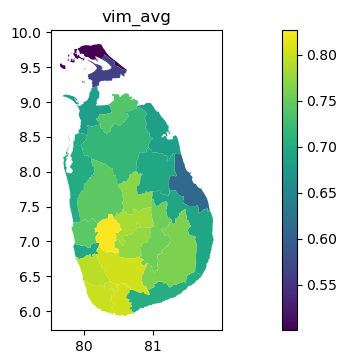

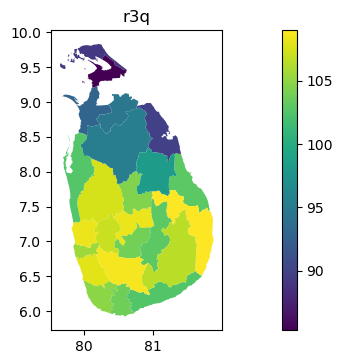

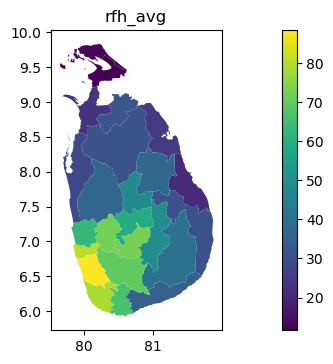

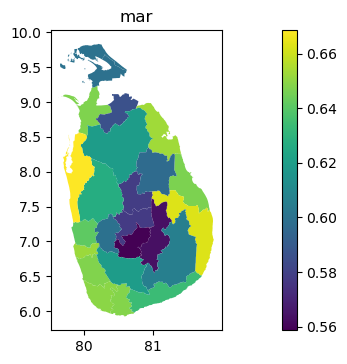

In [48]:
variables = list(['vim_avg','r3q', 'rfh_avg', 'mar'])

for item in variables:
    print(item)
    fig = plt.figure(figsize=[12,3])
    ax = fig.add_axes([0, 0, 1, 1])
    climate_shp.plot(column = item,ax = ax,legend=True  )
    ax.set_title(item)
    